LOAD DATA

In [5]:
import pandas as pd

train = pd.read_csv("../datasets/train.csv")
test = pd.read_csv("../datasets/test.csv")

train.head()

,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
0,1,Male,Urban,Bachelor,5L-10L,1,5,5790,More than 1,A,Platinum,64308
1,2,Male,Rural,High School,5L-10L,0,8,5080,More than 1,A,Platinum,515400
2,3,Male,Urban,Bachelor,5L-10L,1,8,2599,More than 1,A,Platinum,64212
3,4,Female,Rural,High School,5L-10L,0,7,0,More than 1,A,Platinum,97920
4,5,Male,Urban,High School,More than 10L,1,6,3508,More than 1,A,Gold,59736


STEP 2: Basic Info

In [6]:
train.shape
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89392 entries, 0 to 89391
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              89392 non-null  int64 
 1   gender          89392 non-null  object
 2   area            89392 non-null  object
 3   qualification   89392 non-null  object
 4   income          89392 non-null  object
 5   marital_status  89392 non-null  int64 
 6   vintage         89392 non-null  int64 
 7   claim_amount    89392 non-null  int64 
 8   num_policies    89392 non-null  object
 9   policy          89392 non-null  object
 10  type_of_policy  89392 non-null  object
 11  cltv            89392 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 8.2+ MB


,id,marital_status,vintage,claim_amount,cltv
count,89392.000000,89392.000000,89392.000000,89392.000000,89392.000000
mean,44696.500000,0.575488,4.595669,4351.502416,97952.828978
std,25805.391969,0.494272,2.290446,3262.359775,90613.814793
min,1.000000,0.000000,0.000000,0.000000,24828.000000
25%,22348.750000,0.000000,3.000000,2406.000000,52836.000000
50%,44696.500000,1.000000,5.000000,4089.000000,66396.000000
75%,67044.250000,1.000000,6.000000,6094.000000,103440.000000
max,89392.000000,1.000000,8.000000,31894.000000,724068.000000


STEP 3: Missing Values

In [7]:
train.isnull().sum()

id                0
gender            0
area              0
qualification     0
income            0
marital_status    0
vintage           0
claim_amount      0
num_policies      0
policy            0
type_of_policy    0
cltv              0
dtype: int64

STEP 4: Target Analysis

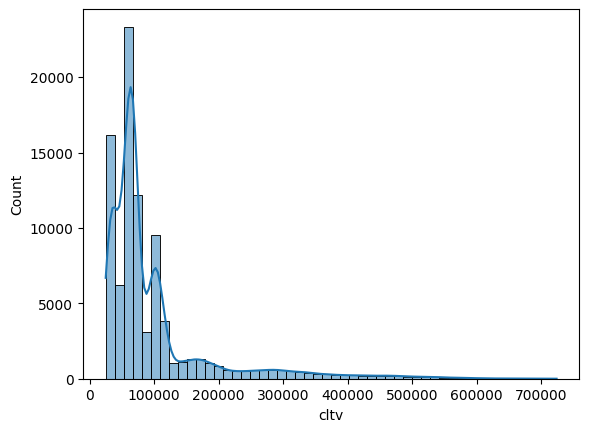

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(train['cltv'], bins=50, kde=True)
plt.show()

STEP 5: Log Transform

In [10]:
import numpy as np

train['cltv'] = np.log1p(train['cltv'])

STEP 6: Drop ID

In [11]:
train.drop(columns=['id'], inplace=True)

test_ids = test['id']
test.drop(columns=['id'], inplace=True)

STEP 7: Encode Categorical

In [12]:
from sklearn.preprocessing import LabelEncoder

cat_cols = train.select_dtypes(include='object').columns

le = LabelEncoder()
for col in cat_cols:
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

STEP 8: Feature Engineering

In [13]:
train['income_per_policy'] = train['income'] / (train['num_policies'] + 1)
test['income_per_policy'] = test['income'] / (test['num_policies'] + 1)

train['claim_ratio'] = train['claim_amount'] / (train['income'] + 1)
test['claim_ratio'] = test['claim_amount'] / (test['income'] + 1)

train['policy_per_year'] = train['num_policies'] / (train['vintage'] + 1)
test['policy_per_year'] = test['num_policies'] / (test['vintage'] + 1)